In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge, Lasso, LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

In [3]:
# Load the dataset
diabetes = load_diabetes()
df = pd.DataFrame(diabetes.data, columns=diabetes.feature_names)
df['target'] = diabetes.target

print(f"Dataset Shape: {df.shape}")
df.head()

Dataset Shape: (442, 11)


,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,target
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646,151.0
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204,75.0
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930,141.0
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362,206.0
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641,135.0


In [4]:
# Define features and target
X = df.drop('target', axis=1)
y = df['target']

In [5]:
# Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [6]:
# Scale the features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [7]:
# Initialize models
models = {
    "Linear Regression": LinearRegression(),
    "Ridge (Alpha=1.0)": Ridge(alpha=1.0),
    "Lasso (Alpha=0.1)": Lasso(alpha=0.1)
}

results = []

for name, model in models.items():
    # Fit model
    model.fit(X_train_scaled, y_train)
    
    # Predict
    y_pred = model.predict(X_test_scaled)
    
    # Calculate metrics
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)
    
    results.append({"Model": name, "RMSE": rmse, "R2 Score": r2})

# Display Results
results_df = pd.DataFrame(results)
results_df

,Model,RMSE,R2 Score
0,Linear Regression,53.853446,0.452603
1,Ridge (Alpha=1.0),53.777454,0.454147
2,Lasso (Alpha=0.1),53.708698,0.455541


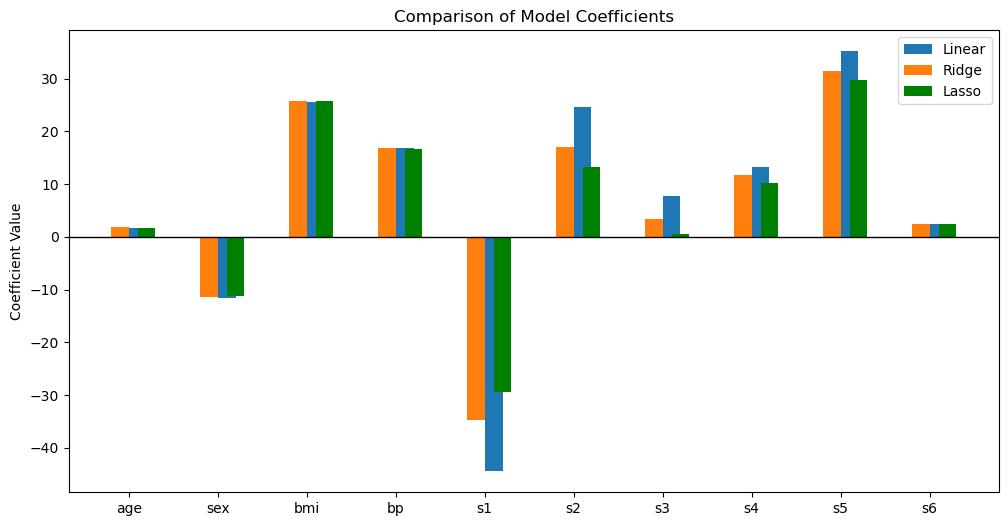

In [8]:
plt.figure(figsize=(12, 6))

# Get coefficients
lr_coef = models["Linear Regression"].coef_
ridge_coef = models["Ridge (Alpha=1.0)"].coef_
lasso_coef = models["Lasso (Alpha=0.1)"].coef_

# Plotting
x_range = range(len(diabetes.feature_names))
plt.bar(x_range, lr_coef, width=0.2, label='Linear', align='edge')
plt.bar(x_range, ridge_coef, width=-0.2, label='Ridge', align='edge')
plt.bar([x + 0.2 for x in x_range], lasso_coef, width=0.2, label='Lasso', color='green')

plt.xticks(x_range, diabetes.feature_names)
plt.ylabel('Coefficient Value')
plt.title('Comparison of Model Coefficients')
plt.legend()
plt.axhline(0, color='black', lw=1)
plt.show()